In [81]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from scipy.stats import kruskal

In [82]:
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "#4A4A4A",
    "axes.linewidth": 0.8,
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "font.size": 15,
    "font.family": "DejaVu Sans",
    "legend.fontsize": 14,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [83]:
PROJECT_ROOT = Path("../../results/")

DATA_DIR = PROJECT_ROOT / "processed_hrv"
RESULTS_DIR = PROJECT_ROOT

EDA_TABLES = RESULTS_DIR / "eda_tables"
NP_TABLES = RESULTS_DIR / "nonparametric_tables"
NP_INT_TABLES = RESULTS_DIR / "nonparametric_interpretation_tables"
MULTI_TABLES = RESULTS_DIR / "multivariate_tables"

In [84]:
df = pd.read_csv(DATA_DIR / "basal_v2_clean_with_categories.csv")

corr_df = pd.read_csv(EDA_TABLES / "correlation_matrix.csv")
desc_df = pd.read_csv(EDA_TABLES / "descriptive_stats.csv")

freq_sex = pd.read_csv(NP_TABLES / "freq_sex.csv")
freq_age = pd.read_csv(NP_TABLES / "freq_age_group.csv")
freq_bmi = pd.read_csv(NP_TABLES / "freq_bmi_cat.csv")
freq_bp = pd.read_csv(NP_TABLES / "freq_bp_cat.csv")

binary_df = pd.read_csv(NP_TABLES / "binary_group_comparisons_mannwhitney_cliff.csv")
single_df = pd.read_csv(NP_TABLES / "multigroup_kruskal_results.csv")
double_df = pd.read_csv(NP_TABLES / "double_category_kruskal_results.csv")
triple_df = pd.read_csv(NP_TABLES / "triple_category_kruskal_results.csv")

ranking_df = pd.read_csv(NP_INT_TABLES / "hrv_global_discrimination_ranking.csv")

In [85]:
HRV_VARS = [
    "t2m_pre_mean_rr",
    "t2m_pre_mean_hr",
    "t2m_pre_sdnn",
    "t2m_pre_rmssd",
    "t2m_pre_hf",
    "t2m_pre_lf",
    "t2m_pre_vlf",
]

HRV_LABELS = {
    "t2m_pre_mean_rr": "Mean RR",
    "t2m_pre_mean_hr": "Mean HR",
    "t2m_pre_sdnn": "SDNN",
    "t2m_pre_rmssd": "RMSSD",
    "t2m_pre_hf": "HF",
    "t2m_pre_lf": "LF",
    "t2m_pre_vlf": "VLF",
}

GROUP_LABELS = {
    "sex": "Sex",
    "age_group": "Age group",
    "bmi_cat": "BMI",
    "bp_cat": "BP",
    "bp_category": "BP",
    "bp_group": "BP",
    "pressure_cat": "BP",
    "sex__age_group": "Sex × Age",
    "sex__bmi_cat": "Sex × BMI",
    "sex__bp_cat": "Sex × BP",
    "sex__bp_category": "Sex × BP",
    "age_group__bmi_cat": "Age × BMI",
    "age_group__bp_cat": "Age × BP",
    "age_group__bp_category": "Age × BP",
    "bmi_cat__bp_cat": "BMI × BP",
    "bmi_cat__bp_category": "BMI × BP",
    "sex__age_group__bmi_cat": "Sex × Age × BMI",
    "sex__age_group__bp_cat": "Sex × Age × BP",
    "sex__age_group__bp_category": "Sex × Age × BP",
    "sex__bmi_cat__bp_cat": "Sex × BMI × BP",
    "sex__bmi_cat__bp_category": "Sex × BMI × BP",
    "age_group__bmi_cat__bp_cat": "Age × BMI × BP",
    "age_group__bmi_cat__bp_category": "Age × BMI × BP",
}

sex_map = {1: "Women", 2: "Men"}

def pretty_hrv(x):
    return HRV_LABELS.get(x, x)

def pretty_group(x):
    return GROUP_LABELS.get(x, x)

def add_panel_letter(ax, letter):
    ax.text(
        -0.10, 1.06, letter,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="top",
        ha="left",
        color="#111111"
    )

In [86]:
palette_group = {
    "Sex": "#6F8FAF",
    "Age group": "#4F6D7A",
    "BMI category": "#9C89B8",
    "BP category": "#8DAA91",
}

violin_fill = "#C7D8E8"
box_fill = "#5B84B1"
median_color = "#1D3557"

age_palette = {
    "<60": "#D6E4F0",
    "60-69": "#A9C6DD",
    "70-79": "#6F9FC7",
    "80+": "#355C7D",
}

corr_cmap = LinearSegmentedColormap.from_list(
    "soft_blue_green_diverging",
    ["#4A6FA5", "#F6FAF8", "#4C9F8A"]
)

effect_cmap = LinearSegmentedColormap.from_list(
    "soft_effect",
    ["#F8F6FA", "#D8CBE8", "#A98BC3", "#7B5EA7", "#4B2E83"]
)

In [87]:
corr_df = corr_df.rename(columns={corr_df.columns[0]: "variable"})
corr_df["variable"] = corr_df["variable"].map(lambda x: HRV_LABELS.get(x, x))
corr_matrix = corr_df.set_index("variable")
corr_matrix.columns = [HRV_LABELS.get(c, c) for c in corr_matrix.columns]

if "sex" in freq_sex.columns:
    freq_sex["label"] = freq_sex["sex"].map(sex_map)
else:
    freq_sex["label"] = freq_sex.iloc[:, 0].map(sex_map)

freq_age["label"] = freq_age["age_group"]
freq_bmi["label"] = freq_bmi["bmi_cat"].astype(str).str.capitalize()
freq_bp["label"] = freq_bp["bp_cat"].astype(str).str.capitalize()

freq_sex["domain"] = "Sex"
freq_age["domain"] = "Age group"
freq_bmi["domain"] = "BMI category"
freq_bp["domain"] = "BP category"

cohort_df = pd.concat([
    freq_sex[["domain", "label", "n", "pct"]],
    freq_bp[["domain", "label", "n", "pct"]],
    freq_age[["domain", "label", "n", "pct"]],
    freq_bmi[["domain", "label", "n", "pct"]],
], ignore_index=True)

In [89]:
# -----------------------------
# Rebuild BP simple-category results from df
# -----------------------------
bp_rows = []

for var in HRV_VARS:
    tmp = df[[var, "bp_cat"]].dropna().copy()
    groups = [g[var].dropna().values for _, g in tmp.groupby("bp_cat")]

    if len(groups) >= 2 and all(len(g) > 0 for g in groups):
        H, p = kruskal(*groups)
        n = len(tmp)
        k = len(groups)
        eps2 = (H - k + 1) / (n - k) if (n - k) > 0 else np.nan
        eps2 = max(eps2, 0) if pd.notna(eps2) else np.nan
    else:
        p = np.nan
        eps2 = np.nan

    bp_rows.append({
        "value_variable": pretty_hrv(var),
        "grouping_variable": "BP",
        "effect_value": eps2,
        "significant_flag": (p < 0.05) if pd.notna(p) else False
    })

bp_single = pd.DataFrame(bp_rows)

# -----------------------------
# Sex from binary results
# -----------------------------
sex_binary = binary_df.copy()
sex_binary["value_variable"] = sex_binary["value_variable"].map(pretty_hrv)
sex_binary["grouping_variable"] = "Sex"
sex_binary["effect_value"] = sex_binary["cliffs_delta"].abs()
sex_binary["significant_flag"] = sex_binary["significant_fdr"]

sex_binary_small = sex_binary[
    ["value_variable", "grouping_variable", "effect_value", "significant_flag"]
].copy()

# -----------------------------
# Age/BMI from multigroup results
# -----------------------------
single_multi = single_df.copy()
single_multi["value_variable"] = single_multi["value_variable"].map(pretty_hrv)
single_multi["grouping_variable"] = single_multi["grouping_variable"].map(pretty_group)
single_multi["effect_value"] = single_multi["epsilon_squared"]
single_multi["significant_flag"] = single_multi["significant_fdr"]

single_multi = single_multi[
    single_multi["grouping_variable"].isin(["Age group", "BMI"])
][["value_variable", "grouping_variable", "effect_value", "significant_flag"]].copy()

# -----------------------------
# Combine all simple-category results
# -----------------------------
single_combined = pd.concat(
    [sex_binary_small, single_multi, bp_single],
    ignore_index=True
)

single_combined = (
    single_combined
    .groupby(["value_variable", "grouping_variable"], as_index=False)
    .agg(
        effect_value=("effect_value", "max"),
        significant_flag=("significant_flag", "max")
    )
)

single_order = ["Sex", "Age group", "BMI", "BP"]

single_eps = (
    single_combined
    .pivot_table(
        index="value_variable",
        columns="grouping_variable",
        values="effect_value",
        aggfunc="max"
    )
    .reindex(index=[pretty_hrv(v) for v in HRV_VARS], columns=single_order)
)

single_sig = (
    single_combined
    .pivot_table(
        index="value_variable",
        columns="grouping_variable",
        values="significant_flag",
        aggfunc="max"
    )
    .reindex(index=[pretty_hrv(v) for v in HRV_VARS], columns=single_order)
)

# -----------------------------
# Double-category panel
# -----------------------------
double_plot = double_df.copy()
double_plot["value_variable"] = double_plot["value_variable"].map(pretty_hrv)
double_plot["combined_grouping"] = double_plot["combined_grouping"].map(pretty_group)

double_eps = (
    double_plot
    .pivot(index="value_variable", columns="combined_grouping", values="epsilon_squared")
    .reindex(index=[pretty_hrv(v) for v in HRV_VARS])
)

double_sig = (
    double_plot
    .pivot(index="value_variable", columns="combined_grouping", values="significant_fdr")
    .reindex(index=[pretty_hrv(v) for v in HRV_VARS])
)

# -----------------------------
# Triple-category panel
# -----------------------------
triple_plot = triple_df.copy()
triple_plot["value_variable"] = triple_plot["value_variable"].map(pretty_hrv)
triple_plot["combined_grouping"] = triple_plot["combined_grouping"].map(pretty_group)

triple_eps = (
    triple_plot
    .pivot(index="value_variable", columns="combined_grouping", values="epsilon_squared")
    .reindex(index=[pretty_hrv(v) for v in HRV_VARS])
)

triple_sig = (
    triple_plot
    .pivot(index="value_variable", columns="combined_grouping", values="significant_fdr")
    .reindex(index=[pretty_hrv(v) for v in HRV_VARS])
)


In [90]:
ranking_plot = ranking_df.copy()

if "hrv_pretty" not in ranking_plot.columns:
    ranking_plot["hrv_pretty"] = ranking_plot["value_variable"].map(pretty_hrv)
else:
    ranking_plot["hrv_pretty"] = ranking_plot["hrv_pretty"].fillna(
        ranking_plot["value_variable"].map(pretty_hrv)
    )

ranking_g = (
    ranking_plot.groupby("hrv_pretty", as_index=False)
    .agg(
        total_sig=("n_sig", "sum"),
        best_eps=("max_eps2", "max")
    )
    .sort_values(["total_sig", "best_eps"], ascending=[False, False])
)

In [91]:
def draw_cohort_panel(ax, cohort_df, palette_group):
    domain_order = ["Sex", "BP category", "Age group", "BMI category"]

    y_positions = []
    labels = []
    values = []
    colors = []
    start = 0

    for domain in domain_order:
        tmp = cohort_df[cohort_df["domain"] == domain].copy()
        ys = list(range(start, start + len(tmp)))

        y_positions.extend(ys)
        labels.extend(tmp["label"].tolist())
        values.extend(tmp["pct"].tolist())
        colors.extend([palette_group[domain]] * len(tmp))

        start += len(tmp) + 1

    ax.barh(
        y_positions,
        values,
        color=colors,
        edgecolor="#FFFFFF",
        linewidth=0.8,
        height=0.72,
        hatch="///",
        alpha=0.95
    )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=13)
    ax.set_xlabel("Percentage of cohort", fontsize=14)
    ax.invert_yaxis()
    ax.set_xlim(0, max(values) + 18)

    for y, val in zip(y_positions, values):
        ax.text(val + 0.8, y, f"{val:.1f}%", va="center", fontsize=11, color="#333333")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.15, linewidth=0.7)

    legend_handles = [
        Patch(facecolor=palette_group[d], edgecolor="#FFFFFF", hatch="///", label=d)
        for d in domain_order
    ]
    ax.legend(
        handles=legend_handles,
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        fontsize=11
    )


def draw_violin_box(ax, data_dict, ylabel=None, log_scale=False):
    labels = list(data_dict.keys())
    values = [np.asarray(v) for v in data_dict.values()]

    vp = ax.violinplot(
        values,
        positions=np.arange(1, len(labels) + 1),
        showmeans=False,
        showmedians=False,
        showextrema=False
    )
    for body in vp["bodies"]:
        body.set_facecolor("#BFD3E6")
        body.set_edgecolor("none")
        body.set_alpha(0.95)

    ax.boxplot(
        values,
        positions=np.arange(1, len(labels) + 1),
        widths=0.16,
        patch_artist=True,
        medianprops={"color": median_color, "linewidth": 1.5},
        whiskerprops={"color": "#555555", "linewidth": 1.0},
        capprops={"color": "#555555", "linewidth": 1.0},
        boxprops={"facecolor": "#6F9FC7", "edgecolor": "#555555", "linewidth": 1.0},
        flierprops={"marker": "o", "markersize": 3.5, "markerfacecolor": "white", "markeredgecolor": "#333333", "alpha": 0.9}
    )

    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=28, ha="right", fontsize=11)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if log_scale:
        ax.set_yscale("log")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.15, linewidth=0.7)


def draw_triangular_corr_heatmap(ax, corr_matrix):
    corr = corr_matrix.copy()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    masked = corr.mask(mask)

    im = ax.imshow(masked.values, cmap=corr_cmap, vmin=-1, vmax=1)

    ax.set_xticks(np.arange(corr.shape[1]))
    ax.set_yticks(np.arange(corr.shape[0]))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=11)
    ax.set_yticklabels(corr.index, fontsize=11)

    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            if mask[i, j]:
                continue
            val = corr.iloc[i, j]
            ax.text(
                j, i, f"{val:.1f}",
                ha="center", va="center",
                fontsize=10.2,
                color="white" if abs(val) > 0.45 else "#1F2A2E"
            )

    ax.set_xlim(-0.5, corr.shape[1] - 0.5)
    ax.set_ylim(corr.shape[0] - 0.5, -0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return im


def draw_effect_heatmap(ax, data, sig_mask=None, cmap=effect_cmap, vmin=0, vmax=None):
    if vmax is None:
        vmax = np.nanmax(data.values)

    im = ax.imshow(data.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_xticklabels(data.columns, rotation=28, ha="right", fontsize=12)
    ax.set_yticklabels(data.index, fontsize=12)

    threshold = vmax * 0.55 if vmax > 0 else 0.1

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.iloc[i, j]
            if pd.isna(val):
                continue
            txt = f"{val:.2f}"
            if sig_mask is not None:
                sig = sig_mask.iloc[i, j]
                if pd.notna(sig) and bool(sig):
                    txt += "*"
            ax.text(
                j, i, txt,
                ha="center", va="center",
                fontsize=11,
                color="white" if val >= threshold else "#1F1F1F"
            )

    return im


def grouped_boxplot_with_hue(
    ax,
    df,
    x,
    y,
    hue,
    order=None,
    hue_order=None,
    palette=None,
    ylabel=None,
    log_scale=False,
    show_legend=False
):
    tmp = df[[x, y, hue]].dropna().copy()

    if order is None:
        order = list(pd.unique(tmp[x]))
    if hue_order is None:
        hue_order = list(pd.unique(tmp[hue]))

    n_groups = len(order)
    n_hues = len(hue_order)
    width = 0.16

    centers = np.arange(n_groups) + 1
    offsets = np.linspace(-width * (n_hues - 1), width * (n_hues - 1), n_hues) / 1.2

    legend_handles = []

    for h_idx, h in enumerate(hue_order):
        this_color = palette[h] if palette is not None else "#5B84B1"
        legend_handles.append(Patch(facecolor=this_color, edgecolor="#444444", label=str(h)))

        data = []
        positions = []

        for g_idx, g in enumerate(order):
            vals = tmp.loc[(tmp[x] == g) & (tmp[hue] == h), y].dropna().values
            if len(vals) == 0:
                vals = np.array([np.nan])
            data.append(vals)
            positions.append(centers[g_idx] + offsets[h_idx])

        ax.boxplot(
            data,
            positions=positions,
            widths=width,
            patch_artist=True,
            showfliers=True,
            medianprops={"color": "#1D3557", "linewidth": 1.5},
            whiskerprops={"color": "#444444", "linewidth": 1.0},
            capprops={"color": "#444444", "linewidth": 1.0},
            boxprops={"facecolor": this_color, "edgecolor": "#444444", "linewidth": 1.0},
            flierprops={
                "marker": "o",
                "markersize": 3.5,
                "markerfacecolor": "white",
                "markeredgecolor": "#333333",
                "alpha": 0.9
            }
        )

    ax.set_xticks(centers)
    ax.set_xticklabels(order, fontsize=11)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if log_scale:
        ax.set_yscale("log")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.15, linewidth=0.7)

    if show_legend:
        ax.legend(handles=legend_handles, frameon=False, loc="upper right")

    return legend_handles

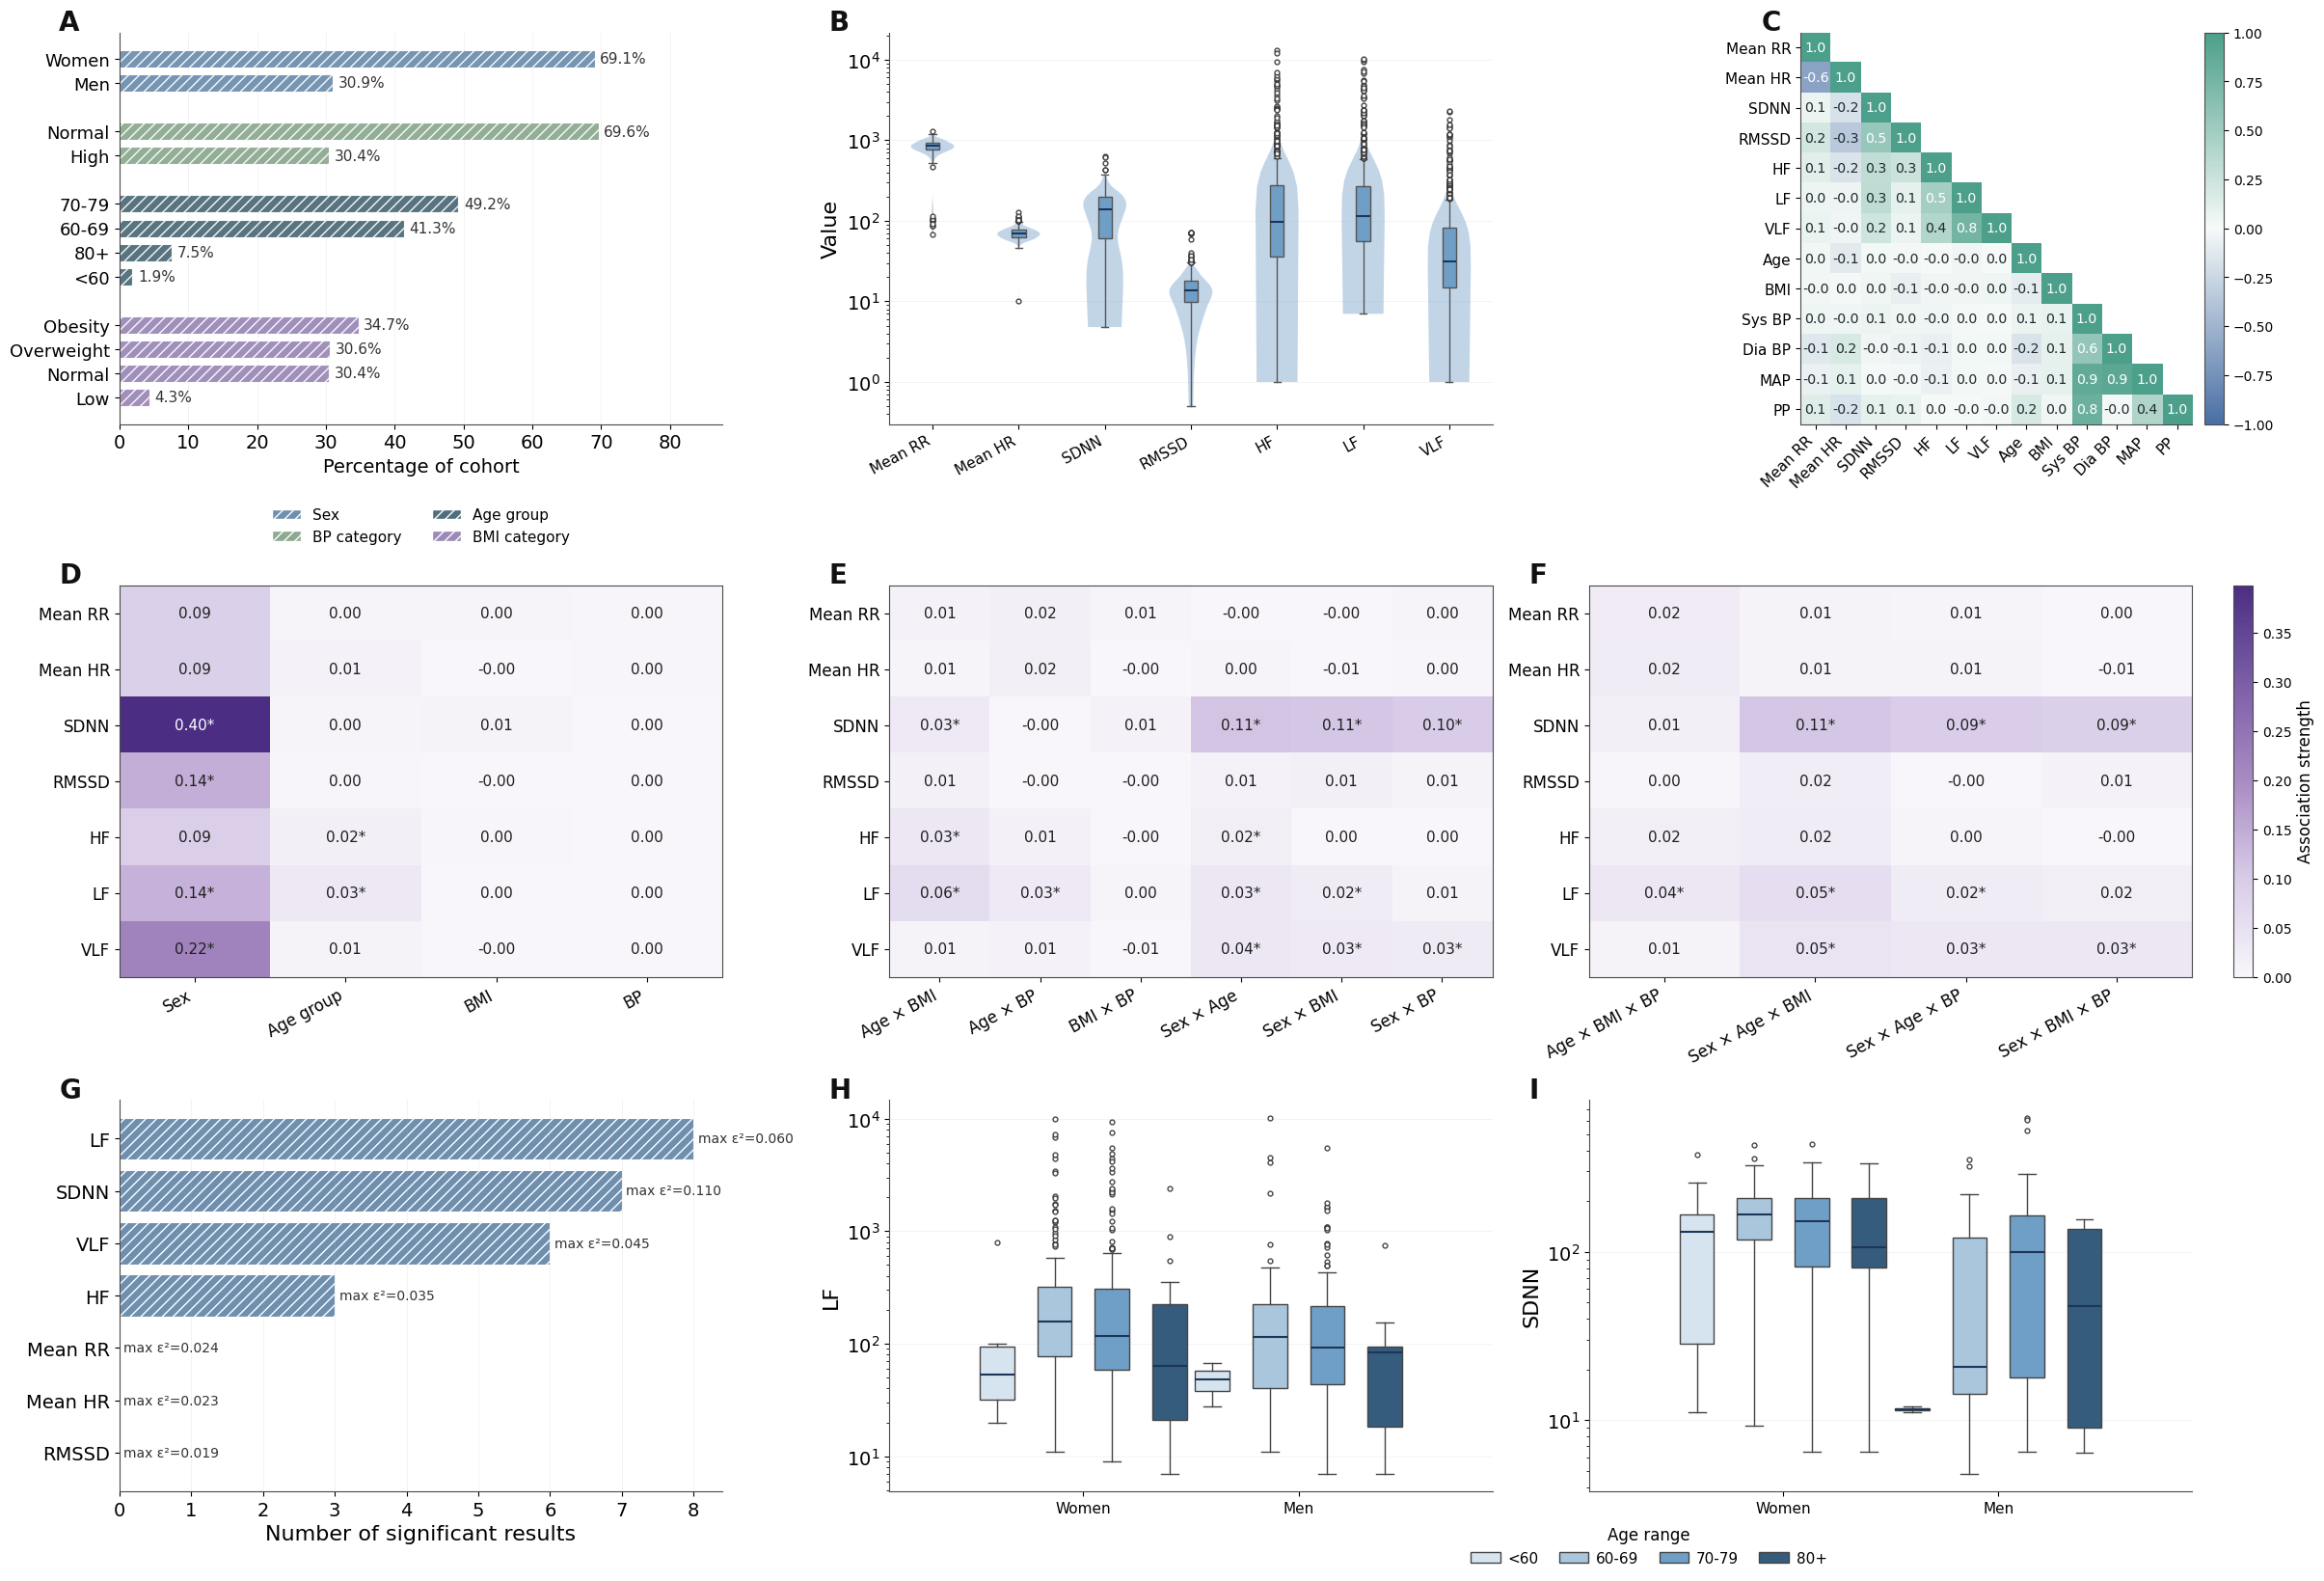

In [101]:
fig = plt.figure(figsize=(24, 16), constrained_layout=True)
gs = fig.add_gridspec(3, 3)

shared_vmax = np.nanmax([
    np.nanmax(single_eps.values),
    np.nanmax(double_eps.values),
    np.nanmax(triple_eps.values)
])

age_order = ["<60", "60-69", "70-79", "80+"]
age_order = [x for x in age_order if x in df["age_group"].dropna().astype(str).unique()]

# ======================
# ROW 1
# ======================

# A
axA = fig.add_subplot(gs[0, 0])
draw_cohort_panel(axA, cohort_df, palette_group)
add_panel_letter(axA, "A")

# B
axB = fig.add_subplot(gs[0, 1])
hrv_for_plot = {pretty_hrv(v): df[v].dropna().values for v in HRV_VARS}
draw_violin_box(axB, hrv_for_plot, ylabel="Value", log_scale=True)
add_panel_letter(axB, "B")

# C
axC = fig.add_subplot(gs[0, 2])

# abreviaciones más compactas para que respire mejor
corr_plot = corr_matrix.copy()
rename_corr = {
    "Mean RR": "Mean RR",
    "Mean HR": "Mean HR",
    "SDNN": "SDNN",
    "RMSSD": "RMSSD",
    "HF": "HF",
    "LF": "LF",
    "VLF": "VLF",
    "age": "Age",
    "imc_final": "BMI",
    "bp_systolic": "Sys BP",
    "bp_diastolic": "Dia BP",
    "bp_pam": "MAP",
    "bp_pp": "PP",
}
corr_plot.index = [rename_corr.get(x, x) for x in corr_plot.index]
corr_plot.columns = [rename_corr.get(x, x) for x in corr_plot.columns]

imC = draw_triangular_corr_heatmap(axC, corr_plot)
cbarC = fig.colorbar(imC, ax=axC, fraction=0.04, pad=0.02)
cbarC.ax.tick_params(labelsize=10)
add_panel_letter(axC, "C")

# ======================
# ROW 2
# ======================

# D
axD = fig.add_subplot(gs[1, 0])
imD = draw_effect_heatmap(
    axD,
    single_eps,
    sig_mask=single_sig,
    vmin=0,
    vmax=shared_vmax
)
add_panel_letter(axD, "D")

# E
axE = fig.add_subplot(gs[1, 1])
imE = draw_effect_heatmap(
    axE,
    double_eps,
    sig_mask=double_sig,
    vmin=0,
    vmax=shared_vmax
)
add_panel_letter(axE, "E")

# F
axF = fig.add_subplot(gs[1, 2])
imF = draw_effect_heatmap(
    axF,
    triple_eps,
    sig_mask=triple_sig,
    vmin=0,
    vmax=shared_vmax
)
add_panel_letter(axF, "F")

# Shared colorbar for D/E/F
cbarDEF = fig.colorbar(imF, ax=[axD, axE, axF], fraction=0.02, pad=0.02)
cbarDEF.ax.tick_params(labelsize=10)
cbarDEF.set_label("Association strength", fontsize=12)

# ======================
# ROW 3
# ======================

# G
axG = fig.add_subplot(gs[2, 0])
axG.barh(
    ranking_g["hrv_pretty"],
    ranking_g["total_sig"],
    color="#6F8FAF",
    edgecolor="#FFFFFF",
    linewidth=0.8,
    hatch="///"
)
axG.set_xlabel("Number of significant results")
axG.invert_yaxis()
axG.spines["top"].set_visible(False)
axG.spines["right"].set_visible(False)
axG.grid(axis="x", alpha=0.15, linewidth=0.7)

for i, (_, row) in enumerate(ranking_g.iterrows()):
    axG.text(
        row["total_sig"] + 0.06,
        i,
        f"max ε²={row['best_eps']:.3f}",
        va="center",
        fontsize=10,
        color="#333333"
    )

add_panel_letter(axG, "G")

# H
axH = fig.add_subplot(gs[2, 1])

legend_handles_age = grouped_boxplot_with_hue(
    axH,
    df=df,
    x="sex",
    y="t2m_pre_lf",
    hue="age_group",
    order=[1, 2],
    hue_order=age_order,
    palette=age_palette,
    ylabel="LF",
    log_scale=True,
    show_legend=False
)
axH.set_xticklabels(["Women", "Men"], fontsize=11)

# un poco más de aire lateral
axH.margins(x=0.12)

add_panel_letter(axH, "H")

# I
axI = fig.add_subplot(gs[2, 2])

grouped_boxplot_with_hue(
    axI,
    df=df,
    x="sex",
    y="t2m_pre_sdnn",
    hue="age_group",
    order=[1, 2],
    hue_order=age_order,
    palette=age_palette,
    ylabel="SDNN",
    log_scale=True,
    show_legend=False
)
axI.set_xticklabels(["Women", "Men"], fontsize=11)
axI.margins(x=0.12)

add_panel_letter(axI, "I")

# Shared legend for H and I
fig.legend(
    handles=legend_handles_age,
    labels=[h.get_label() for h in legend_handles_age],
    title="Age range",
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.71, -0.02),
    ncol=len(age_order),
    fontsize=11,
    title_fontsize=12,
    columnspacing=1.4,
    handletextpad=0.5
)

plt.show()

In [96]:
OUT_DIR = PROJECT_ROOT / "paper_figures"
OUT_DIR.mkdir(exist_ok=True, parents=True)

png_path = OUT_DIR / "figure_1.png"
pdf_path = OUT_DIR / "figure_1.pdf"

fig.savefig(png_path, dpi=400, bbox_inches="tight")
fig.savefig(pdf_path, dpi=400, bbox_inches="tight")

print("Saved:")
print(png_path)
print(pdf_path)

Saved:
../../results/paper_figures/figure_1.png
../../results/paper_figures/figure_1.pdf
